<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Wee_Day_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import io
import requests
import zipfile

# --- CHARGEMENT DES DONNÉES ---
# Téléchargement et extraction du fichier ZIP directement depuis le lien GitHub
url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Pokemon%20Data%20Analysis%20Tutorial.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Lecture des fichiers CSV en utilisant les chemins corrects trouvés dans le zip
pokemon_df = pd.read_csv(zip_file.open('Pokemon Data Analysis Tutorial/pokemon.csv'))
combats_df = pd.read_csv(zip_file.open('Pokemon Data Analysis Tutorial/combats.csv'))

# --- NETTOYAGE DES DONNÉES ---
# 1. Correction du nom manquant pour le Pokémon #62 (Primeape)
# Dans le dataset, l'index ou l'ID correspond généralement à la colonne '#'
pokemon_df.loc[pokemon_df['#'] == 62, 'Name'] = 'Primeape'

# 2. Gestion des valeurs manquantes pour 'Type 2'
pokemon_df['Type 2'] = pokemon_df['Type 2'].fillna('None')

# --- INGIÉNIERIE DES VARIABLES (FEATURE ENGINEERING) ---
# Calcul du taux de victoire à partir de combats_df

# Nombre total de combats par Pokémon (qu'il soit en position 1 ou 2)
total_combats_p1 = combats_df['First_pokemon'].value_counts()
total_combats_p2 = combats_df['Second_pokemon'].value_counts()
total_combats = total_combats_p1.add(total_combats_p2, fill_value=0)

# Nombre total de victoires par Pokémon
total_wins = combats_df['Winner'].value_counts()

# Création d'un DataFrame temporaire pour calculer le pourcentage
stats_combats_df = pd.DataFrame({
    'Total_Combats': total_combats,
    'Total_Wins': total_wins
}).fillna(0)

stats_combats_df['Win_Percentage'] = (stats_combats_df['Total_Wins'] / stats_combats_df['Total_Combats']) * 100

# Fusion (Merge) du taux de victoire avec le DataFrame principal des Pokémon
# On aligne l'ID du Pokémon '#' avec l'index du calcul des combats
pokemon_cleaned_df = pokemon_df.merge(stats_combats_df['Win_Percentage'], left_on='#', right_index=True, how='left')

# Si un Pokémon n'a fait aucun combat, son taux de victoire est mis à 0
pokemon_cleaned_df['Win_Percentage'] = pokemon_cleaned_df['Win_Percentage'].fillna(0)

print("Aperçu du dataset nettoyé :")
print(pokemon_cleaned_df[['#', 'Name', 'Type 1', 'Type 2', 'Win_Percentage']].head())

Aperçu du dataset nettoyé :
   #           Name Type 1  Type 2  Win_Percentage
0  1      Bulbasaur  Grass  Poison       27.819549
1  2        Ivysaur  Grass  Poison       38.016529
2  3       Venusaur  Grass  Poison       67.424242
3  4  Mega Venusaur  Grass  Poison       56.000000
4  5     Charmander   Fire    None       49.107143


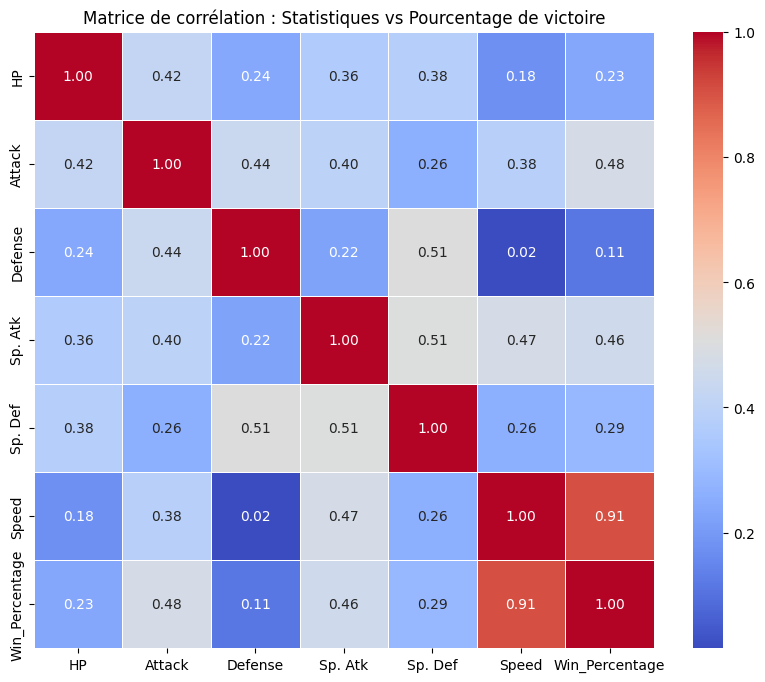

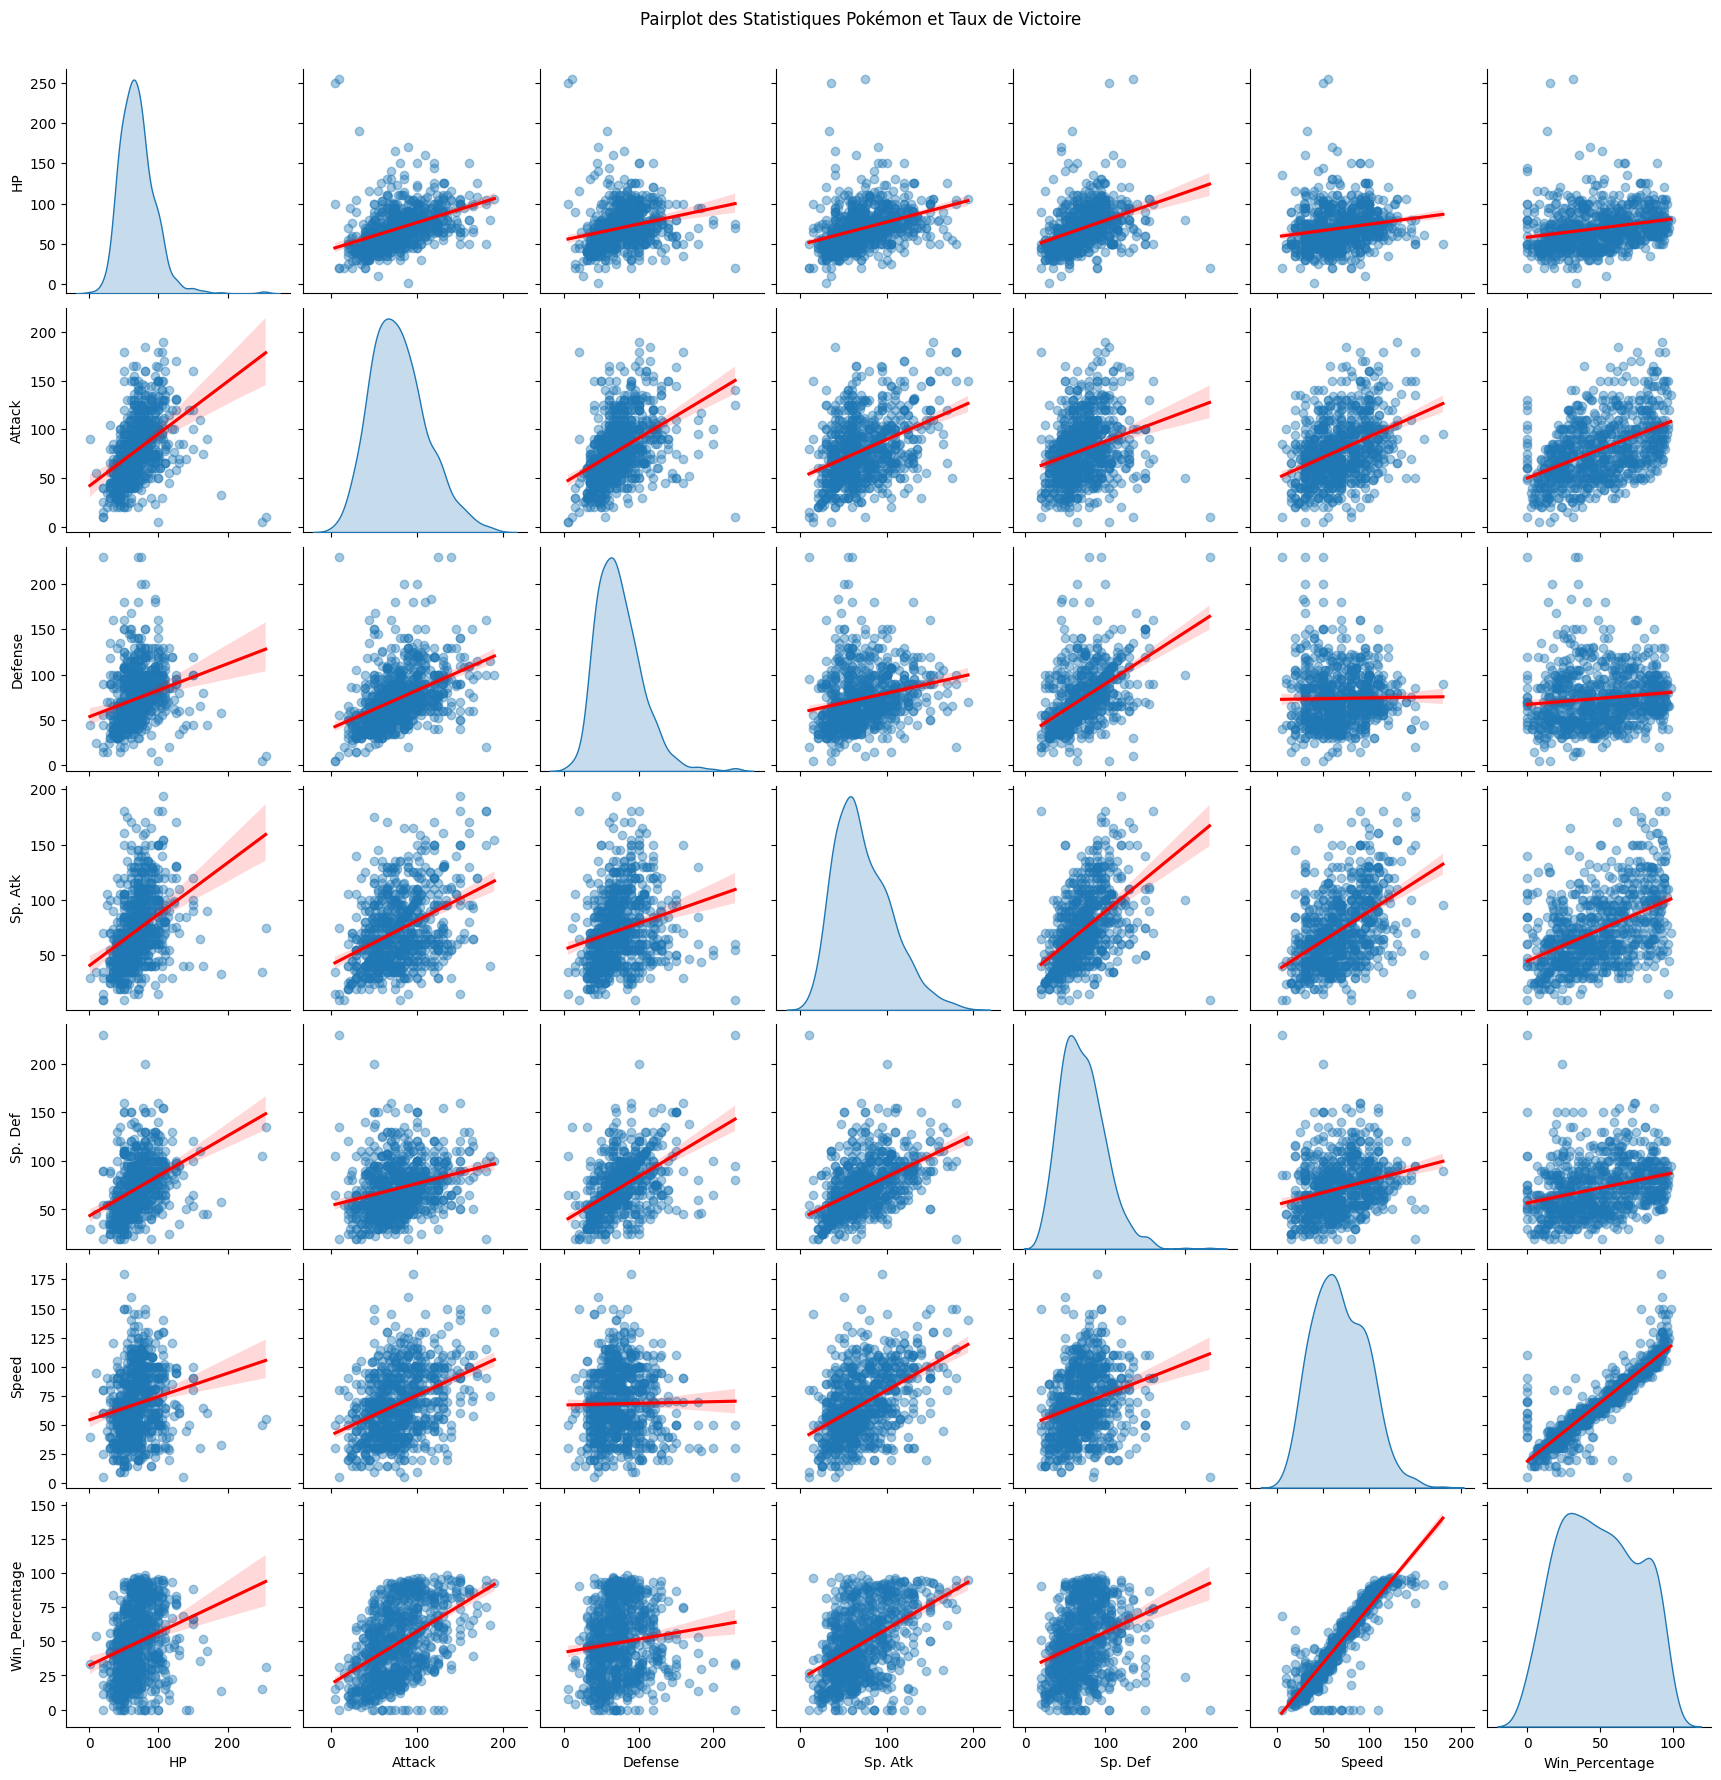


--- TOP 10 DES POKÉMON PAR TAUX DE VICTOIRE ---
                         Name  Win_Percentage  Speed  Attack   HP
154           Mega Aerodactyl       98.449612    150     135   80
512                   Weavile       97.478992    125     120   70
703    Tornadus Therian Forme       96.800000    121     100   79
19              Mega Beedrill       96.638655    145     150   65
153                Aerodactyl       96.453901    130     105   80
476              Mega Lopunny       96.124031    135     136   65
726                  Greninja       96.062992    122      95   72
716  Meloetta Pirouette Forme       95.934959    128     128  100
164             Mega Mewtwo Y       95.200000    140     150  106
349             Mega Sharpedo       95.000000    105     140   70


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des colonnes numériques représentatives des statistiques de combat
stats_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']

# --- MATRICE DE CORRÉLATION ---
plt.figure(figsize=(10, 8))
correlation_matrix = pokemon_cleaned_df[stats_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation : Statistiques vs Pourcentage de victoire')
plt.show()

# --- PAIRPLOT / PAIRGRID ---
# Visualisation des relations globales (échantillonnage optionnel si le rendu est trop lourd)
sns.pairplot(pokemon_cleaned_df[stats_columns], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4}})
plt.suptitle('Pairplot des Statistiques Pokémon et Taux de Victoire', y=1.02)
plt.show()

# --- ANALYSE DES TOP 10 POKÉMON ---
top_10_pokemon = pokemon_cleaned_df.sort_values(by='Win_Percentage', ascending=False).head(10)
print("\n--- TOP 10 DES POKÉMON PAR TAUX DE VICTOIRE ---")
print(top_10_pokemon[['Name', 'Win_Percentage', 'Speed', 'Attack', 'HP']])


--- ÉVALUATION DES MODÈLES (MAE) ---
Régression Linéaire -> MAE: 6.37%
Random Forest -> MAE: 5.76%
XGBoost -> MAE: 5.88%


/tmp/ipykernel_3257/380719779.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(mae_results.keys()), y=list(mae_results.values()), palette='viridis')


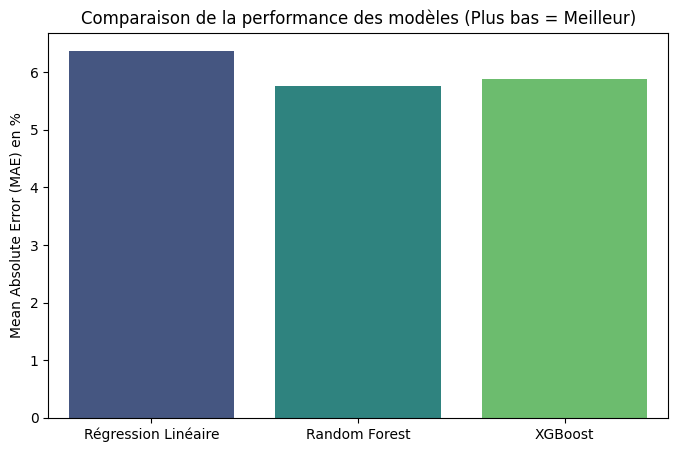

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# --- PRÉPARATION DES MATRICES DE DONNÉES ---
# Sélection des caractéristiques numériques (Features)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']

# Conversion de la colonne booléenne 'Legendary' en données numériques (0 ou 1)
pokemon_cleaned_df['Legendary'] = pokemon_cleaned_df['Legendary'].astype(int)

X = pokemon_cleaned_df[features]
y = pokemon_cleaned_df['Win_Percentage']

# Division des données : 80% Entraînement / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- ENTRAÎNEMENT & ÉVALUATION DES MODÈLES ---
models = {
    "Régression Linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

mae_results = {}

print("\n--- ÉVALUATION DES MODÈLES (MAE) ---")
for name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Calcul de l'erreur absolue moyenne
    mae = mean_absolute_error(y_test, y_pred)
    mae_results[name] = mae
    print(f"{name} -> MAE: {mae:.2f}%")

# --- COMPARAISON VISUELLE ---
plt.figure(figsize=(8, 5))
sns.barplot(x=list(mae_results.keys()), y=list(mae_results.values()), palette='viridis')
plt.ylabel('Mean Absolute Error (MAE) en %')
plt.title('Comparaison de la performance des modèles (Plus bas = Meilleur)')
plt.show()

/tmp/ipykernel_3257/3553554423.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Statistique', data=importance_df, palette='mako')


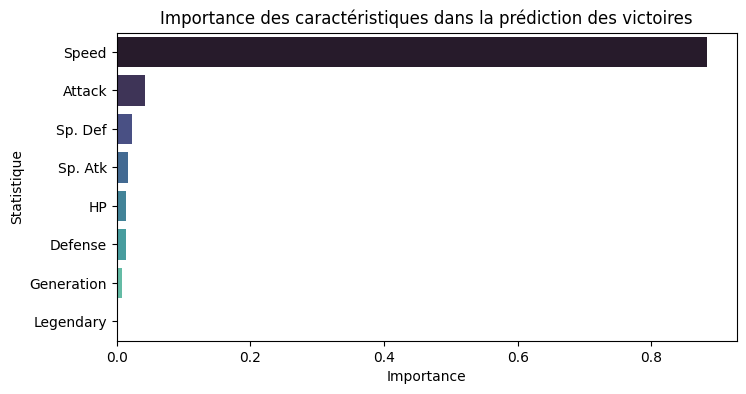

In [6]:
# Extraction de l'importance des variables avec Random Forest
importances = models["Random Forest"].feature_importances_
importance_df = pd.DataFrame({'Statistique': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graphique
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Statistique', data=importance_df, palette='mako')
plt.title('Importance des caractéristiques dans la prédiction des victoires')
plt.show()